# 04 · Kernels, fusion strategies and MKL (protocol §4–5.2)

This notebook builds every classifier in the protocol from one ingredient: a support vector machine on a kernel.

## 1. Linear classifiers and the support vector machine
A linear classifier gives each participant a **decision score**

$$f(x) = w^\top x + b,$$

and classifies them as a patient when $f(x)$ is at or above a threshold (notebook 05).

The **support vector machine (SVM)** chooses the weights $w$ and intercept $b$ by solving

$$\min_{w,b}\ \underbrace{\tfrac12\|w\|_2^2}_{\text{L2 regularization}} \;+\; C\sum_{i=1}^{n} c_{y_i}\,\underbrace{\max\!\big(0,\ 1 - \tilde y_i f(x_i)\big)}_{\text{hinge loss}},\qquad \tilde y_i \in\{-1,+1\}.$$

Each part of this formula:
- **Hinge loss.** Zero for a participant who is on the correct side with a margin of at least 1; grows linearly for anyone closer to, or on the wrong side of, the boundary.
- **L2 regularization.** Penalizes large weights, which gives smoother and more stable models. It is essential when $p \gg n$: with 4,950 features and about 120 training participants, a hyperplane that separates the training data perfectly *always* exists, even for pure noise.
- **C (regularization strength).** The trade-off between the two terms:
  - *small C* means strong regularization, a wide margin, and tolerance of training errors;
  - *large C* means the model fits the training data tightly.

  C is chosen by the inner CV from the grid $\{0.001, 0.01, 0.1, 1, 10, 100\}$.
- **Class weights** $c_y = n / (2\,n_y)$ (`class_weight="balanced"`). Each class contributes equally to the loss, even when one class is smaller.

## 2. Kernels
The SVM solution can always be written as $w = \sum_i \alpha_i \tilde y_i x_i$ (the **dual** form). The decision score then becomes

$$f(x) = \sum_i \alpha_i\tilde y_i\,\langle x_i, x\rangle + b .$$

**Only inner products between participants are needed.** A **kernel** $k(x, x')$ is a similarity between two participants, and the **kernel (Gram) matrix** $K_{ij} = k(x_i, x_j)$ is an $n \times n$ table of all pairwise similarities.

- **Linear kernel:** $k(x, x') = x^\top x'$. With standardized features $Z$, the kernel matrix is $K = ZZ^\top$.
- **Why kernels help here:**
  - The SVM works with a 120 × 120 matrix whether a modality has 150 features or 4,950.
  - Fusion becomes a question of *adding similarity matrices*.
- **Valid kernels** are positive semidefinite (PSD): all eigenvalues are ≥ 0.
- **How we use it in scikit-learn.** `SVC(kernel="precomputed")` is fit on the **training kernel** (train × train) and predicts from the **cross-kernel** (test × train). Test participants never enter the training kernel.
- A linear-kernel SVM is *exactly* the L2-regularized, hinge-loss linear SVM that the protocol specifies. It is simply computed in dual form.

## 3. Standardization, kernel normalization and centering

**Standardization (z-scoring).** Each feature is transformed as $z = (x - \mu_{\text{train}})/\sigma_{\text{train}}$, using the mean and SD of the *training* participants only.

**Kernel normalization (trace normalization).**

$$\tilde K = K / s, \qquad s = \tfrac{1}{n_{\text{train}}}\operatorname{tr}(K_{\text{train}}) \quad(\text{mean self-similarity}).$$

- **What it does:** after normalization, the average training participant has a similarity of 1 with themselves.
- **What $s$ equals:** with z-scored features, $s$ is exactly the number of non-constant features.
- **Leak-free:** the same scalar $s$, computed from training data, also divides the cross-kernel.
- **Why it matters:** without it, the entries of $K_f$ would be about 33 times larger than those of $K_s$ simply because $X_f$ has about 33 times more features. The functional block would dominate any combination.

**Centering.** $K_c = HKH$ with $H = I - \tfrac1n\mathbf 1\mathbf 1^\top$ is the kernel of mean-centred features. The protocol does **not** centre the SVM kernels, for two reasons:
1. the features are already centred by training-fold standardization;
2. an SVM with an intercept $b$ is unaffected by shifting all features by a constant.

Centred kernels are used only inside the kernel-alignment sensitivity estimator (section 6).

## 4. Three ways to fuse two modalities

| Strategy | How | In this project |
|---|---|---|
| **Early fusion** | concatenate $[X_s, X_f]$ and train one model | `early_fusion` |
| **Kernel fusion** | combine the modality kernels: $K = \beta_s K_s + \beta_f K_f$ | `equal_weight` ($\beta_s = 0.5$), `mkl` (learned β) |
| **Late fusion (stacking)** | train one model per modality, then combine their scores with a second model | `stacking` |
| Unimodal baselines | one modality only; the floor every fusion strategy must beat | `structural`, `functional` |

### Early fusion is a dimension-weighted kernel sum
After z-scoring, concatenating the blocks gives

$$[Z_s, Z_f][Z_s, Z_f]^\top = Z_sZ_s^\top + Z_fZ_f^\top = p_s\tilde K_s + p_f\tilde K_f .$$

After trace normalization by $p_s + p_f$, early fusion **is** kernel fusion with weights $\beta_s = p_s/(p_s+p_f)$. With 150 structural and 4,950 functional features, the structural block gets **$\beta_s \approx 0.03$**: it is almost ignored.

### Dimensionality is not the only reason one modality can dominate
Even after standardization and trace normalization, a modality can dominate because of:
- **redundancy:** many highly correlated features act like a few strong ones, concentrating the kernel's similarity in a few directions (Demo 3);
- **correlation structure:** the effective number of independent dimensions differs between blocks;
- **noise:** a noisier block adds similarity that carries no label information;
- **feature variance:** z-scoring equalizes each feature, but not how variance is distributed across feature directions;
- **kernel scale:** trace normalization equalizes overall scale only;
- **regularization:** one C is shared by the combined kernel, so it cannot suit both blocks equally;
- **preprocessing choices:** for example, denoising changes the variance of connectivity.

For these reasons the fusion strategies are compared **empirically, under identical splits**, and learned weights β are read as the model's mixture of kernels, not as the biological importance of a modality.

## 5. Multiple kernel learning (MKL)

$$K = \beta_s\tilde K_s + \beta_f\tilde K_f,\qquad \beta_s, \beta_f \ge 0,\quad \beta_s + \beta_f = 1 .$$

**The simplex constraint** (non-negative weights that sum to 1):
- **Non-negative**, because a weighted sum of PSD kernels with non-negative weights is itself PSD, so it is a valid kernel. A negative weight could break this.
- **Summing to 1**, because multiplying the whole kernel by a constant has the same effect as changing C. Fixing the sum removes this redundancy, so the weights are **identifiable**.

**How β is learned here.**
- $\beta_s$ is taken from the grid $\{0, 0.1, \dots, 1\}$ (with $\beta_f = 1 - \beta_s$).
- It is chosen **jointly with C**, by maximizing the mean inner-CV ROC-AUC.
- Ties go to the smallest C, then to the β closest to 0.5.

**Useful consequences of the grid.**
- The grid **nests the simpler models**: $\beta_s = 0$ is the functional model, $\beta_s = 1$ the structural model, and $\beta_s = 0.5$ equal weighting. So MKL can always "fall back" to a simpler model if the data say so.
- **The MKL regularization parameter:** there is none beyond the simplex constraint and the 0.1 grid resolution. Overfitting of β is controlled by nesting, because β is judged only on outer-test participants.

**Other MKL algorithms** (not used, for transparency):
- SimpleMKL, which optimizes β by gradient descent on the SVM objective under the same simplex constraint;
- ℓp-norm MKL;
- EasyMKL.

With only two kernels, an exact grid search is simple, exact and reproducible.

## 6. Centered kernel alignment (sensitivity estimator)
The **alignment** between a kernel and the labels measures how well the kernel's similarities match the "ideal" similarity $yy^\top$, where same-class pairs get +1 and different-class pairs −1:

$$A(K, yy^\top) = \frac{\langle K_c, yy^\top\rangle_F}{\|K_c\|_F\,\|yy^\top\|_F}.$$

The *alignf* method (Cortes, Mohri & Rostamizadeh, 2012) picks the non-negative weights that maximize the alignment of the combined kernel, which amounts to solving a small quadratic program. Unlike the grid, it does not use the SVM at all. It serves as an **alternative MKL estimator in the sensitivity analyses**.

## 7. Late fusion (stacking) and out-of-fold predictions
**How it works.** Two base models, a structural SVM and a functional SVM, each produce a decision score. A **meta-model** (L2 logistic regression) learns how to combine the two scores.

**The trap.** If the meta-model were trained on scores that the base models produced for *their own training participants*, it would see over-confident, overfit scores and learn to trust the most overfit base model.

**The fix: out-of-fold (OOF) scores.** For each inner split:
1. refit the base models on the inner-training participants;
2. score the inner-validation participants.

Every participant then has scores from base models that never saw them, and the meta-model is trained only on those OOF scores.

**A remaining small leak** (documented in protocol §4). The base models' C was selected by an inner CV that included those same participants. The leak stays inside the outer training fold, so the outer test participants are untouched.

## 8. From kernel weights back to feature weights
For interpreting the model and checking its stability (notebook 07), the weight on each standardized feature of modality $m$ can be recovered:

$$w_m = \frac{\beta_m}{s_m}\sum_i \alpha_i\tilde y_i\, z_m(x_i), \qquad f(x) = \sum_m z_m(x)^\top w_m + b .$$

In [2]:
import sys
print(sys.executable)

import scipy
print(scipy.__version__)

c:\Users\diksh\miniconda3\envs\arena-env\python.exe
1.17.1


In [1]:
from pathlib import Path
import copy
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from scipy.linalg import cholesky, solve_triangular
from scipy.optimize import nnls
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
NOTEBOOKS = ROOT / "notebooks"


def use_notebook(name):
    """Run the definition cells (tagged "library") of another notebook in this namespace."""
    notebook = json.loads((NOTEBOOKS / name).read_text(encoding="utf-8"))
    for cell in notebook["cells"]:
        if cell["cell_type"] == "code" and "library" in cell["metadata"].get("tags", []):
            exec("".join(cell["source"]), globals())


def load_yaml(path):
    with open(path, encoding="utf-8") as fh:
        return yaml.safe_load(fh)

In [2]:
class ConfoundRegressor:
    """Cross-validated confound regression (Snoek, Miletić & Scholte, 2019); see notebook 07.

    Per-feature OLS slopes on the confounds are estimated from training rows; ``transform``
    removes the confound-explained part from any rows using those slopes.
    """

    def fit(self, X, confounds):
        X = np.asarray(X, dtype=float)
        C = _as_2d(confounds)
        self.confound_mean_ = C.mean(axis=0)
        self.coef_, *_ = np.linalg.lstsq(C - self.confound_mean_, X - X.mean(axis=0), rcond=None)
        return self

    def transform(self, X, confounds):
        C = _as_2d(confounds)
        return np.asarray(X, dtype=float) - (C - self.confound_mean_) @ self.coef_


def _as_2d(values):
    values = np.asarray(values, dtype=float)
    return values[:, None] if values.ndim == 1 else values


class ModalityKernel:
    """Standardize -> (optional confound regression) -> linear kernel -> trace normalization.

    Every statistic (means, SDs, confound slopes, kernel scale) is estimated on the
    training rows passed to ``fit`` and reused unchanged for new rows.
    """

    def __init__(self, normalize="trace", residualize=False):
        if normalize not in ("trace", "none"):
            raise ValueError(f"Unknown kernel normalization {normalize!r}")
        self.normalize = normalize
        self.residualize = residualize

    def fit(self, X, confounds=None):
        X = np.asarray(X, dtype=float)
        if self.residualize:
            if confounds is None:
                raise ValueError("residualize=True requires confounds")
            self.residualizer_ = ConfoundRegressor().fit(X, confounds)
            X = self.residualizer_.transform(X, confounds)
        self.scaler_ = StandardScaler().fit(X)
        self.Z_train_ = self.scaler_.transform(X)
        gram = self.Z_train_ @ self.Z_train_.T
        self.scale_ = float(np.mean(np.diag(gram))) if self.normalize == "trace" else 1.0
        if not self.scale_ > 0:
            raise ValueError("Training kernel has zero trace: every feature is constant in this fold.")
        self.K_train_ = gram / self.scale_
        return self

    def transform_features(self, X, confounds=None):
        """Standardized (and, if configured, residualized) features using training statistics."""
        X = np.asarray(X, dtype=float)
        if self.residualize:
            X = self.residualizer_.transform(X, confounds)
        return self.scaler_.transform(X)

    def cross_kernel(self, X, confounds=None):
        """Kernel between new rows and the training rows, shape (n_new, n_train)."""
        return self.transform_features(X, confounds) @ self.Z_train_.T / self.scale_


def combine_kernels(kernels, weights):
    """``sum_m weights[m] * kernels[m]`` over the modalities named in ``weights``."""
    total = None
    for name, weight in weights.items():
        if weight == 0:
            continue
        term = weight * kernels[name]
        total = term if total is None else total + term
    if total is None:
        raise ValueError("All kernel weights are zero.")
    return total


def center_kernel(K):
    """Double-center a square training kernel: H K H with H = I - 11'/n."""
    K = np.asarray(K, dtype=float)
    return K - K.mean(axis=0, keepdims=True) - K.mean(axis=1, keepdims=True) + K.mean()


def alignment_weights(kernels, y):
    """Centered kernel alignment weights ("alignf"; Cortes, Mohri & Rostamizadeh, 2012).

    Solves min_{v >= 0} v'Mv - 2v'a with M_kl = <Kc_k, Kc_l>_F and a_k = <Kc_k, yy'>_F,
    then rescales v onto the simplex. Training kernels only.
    """
    names = list(kernels)
    y_pm = np.where(np.asarray(y) == 1, 1.0, -1.0)
    target = np.outer(y_pm, y_pm)
    centered = [center_kernel(kernels[name]) for name in names]
    M = np.array([[np.sum(a * b) for b in centered] for a in centered])
    a = np.array([np.sum(Kc * target) for Kc in centered])
    L = cholesky(M + 1e-10 * np.trace(M) * np.eye(len(names)), lower=True)
    v, _ = nnls(L.T, solve_triangular(L, a, lower=True))
    if v.sum() <= 0:
        v = np.ones(len(names))
    return dict(zip(names, v / v.sum()))

In [3]:
TIE_TOL = 1e-12


def youden_threshold(y, scores):
    """Score threshold maximizing sensitivity + specificity - 1 (explained in notebook 05).

    Participants with ``score >= threshold`` are classified as patients; ties go to the
    threshold closest to 0, the SVM default.
    """
    fpr, tpr, thresholds = roc_curve(y, scores, drop_intermediate=False)
    finite = np.isfinite(thresholds)
    j = tpr[finite] - fpr[finite]
    thresholds = thresholds[finite]
    tied = np.flatnonzero(j >= j.max() - TIE_TOL)
    return float(thresholds[tied[np.argmin(np.abs(thresholds[tied]))]])


class KernelSVM:
    """SVM on a fixed or learned convex combination of modality kernels.

    weighting:
      "fixed"      weights given (default: equal) -> unimodal and equal-weight models
      "grid"       MKL: beta of the first modality chosen jointly with C by inner CV
      "alignment"  centered kernel alignment on the training kernels (sensitivity)
      "concat"     early fusion: one kernel over the concatenated columns
    residualize_on: block of confounds regressed out of every feature within training folds.
    """

    WEIGHTINGS = ("fixed", "grid", "alignment", "concat")

    def __init__(self, name, blocks, modalities, weighting="fixed", weights=None,
                 C_grid=(1.0,), beta_grid=None, residualize_on=None,
                 normalize="trace", class_weight="balanced"):
        if weighting not in self.WEIGHTINGS:
            raise ValueError(f"Unknown weighting {weighting!r}")
        if weighting == "grid" and (len(modalities) != 2 or beta_grid is None or len(beta_grid) == 0):
            raise ValueError("Grid MKL needs exactly two modalities and a beta_grid.")
        if weighting in ("concat", "alignment") and len(modalities) < 2:
            raise ValueError(f"{weighting!r} weighting needs at least two modalities.")
        if weighting == "fixed":
            weights = weights or {m: 1.0 / len(modalities) for m in modalities}
            if (set(weights) != set(modalities) or min(weights.values()) < 0
                    or not np.isclose(sum(weights.values()), 1.0)):
                raise ValueError("Fixed weights must cover the modalities, be nonnegative and sum to 1.")
        needed = list(modalities) + ([residualize_on] if residualize_on else [])
        self.name = name
        self.blocks = {m: np.asarray(blocks[m]) for m in needed}
        self.modalities = list(modalities)
        self.weighting = weighting
        self.weights = weights
        self.C_grid = [float(c) for c in C_grid]
        self.beta_grid = None if beta_grid is None else [float(b) for b in beta_grid]
        self.residualize_on = residualize_on
        self.normalize = normalize
        self.class_weight = class_weight

    # -- kernel construction --
    def _kernel_names(self):
        return ["concat"] if self.weighting == "concat" else self.modalities

    def _columns(self, name):
        if name == "concat":
            return np.concatenate([self.blocks[m] for m in self.modalities])
        return self.blocks[name]

    def _confounds(self, X):
        return X[:, self.blocks[self.residualize_on]] if self.residualize_on else None

    def _fit_kernels(self, X):
        confounds = self._confounds(X)
        return {name: ModalityKernel(self.normalize, residualize=confounds is not None)
                .fit(X[:, self._columns(name)], confounds)
                for name in self._kernel_names()}

    def _cross_kernels(self, kernels, X):
        confounds = self._confounds(X)
        return {name: k.cross_kernel(X[:, self._columns(name)], confounds) for name, k in kernels.items()}

    def _configs(self):
        betas = self.beta_grid if self.weighting == "grid" else [None]
        return [{"C": C, "beta": beta} for beta in betas for C in self.C_grid]

    def _weights(self, config, train_kernels, y):
        if self.weighting == "concat":
            return {"concat": 1.0}
        if self.weighting == "fixed":
            return dict(self.weights)
        if self.weighting == "grid":
            first, second = self.modalities
            return {first: config["beta"], second: 1.0 - config["beta"]}
        return alignment_weights({m: train_kernels[m] for m in self.modalities}, y)

    def _svm(self, C):
        return SVC(kernel="precomputed", C=C, class_weight=self.class_weight)

    # -- fitting --
    def fit(self, X, y, inner_splits):
        """Select (C, beta) and the threshold by inner CV, then refit on all of ``X``."""
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)
        configs = self._configs()
        oof = np.full((len(configs), len(y)), np.nan)
        fold_auc = np.full((len(configs), len(inner_splits)), np.nan)
        for f, (train, val) in enumerate(inner_splits):
            kernels = self._fit_kernels(X[train])
            K_train = {name: k.K_train_ for name, k in kernels.items()}
            K_val = self._cross_kernels(kernels, X[val])
            for c, config in enumerate(configs):
                weights = self._weights(config, K_train, y[train])
                svm = self._svm(config["C"]).fit(combine_kernels(K_train, weights), y[train])
                scores = svm.decision_function(combine_kernels(K_val, weights))
                oof[c, val] = scores
                fold_auc[c, f] = roc_auc_score(y[val], scores)
        if np.isnan(oof).any():
            raise ValueError("Inner splits must place every training participant in exactly one validation fold.")

        mean_auc = fold_auc.mean(axis=1)
        self.inner_results_ = pd.DataFrame(configs).assign(mean_inner_auc=mean_auc)
        tied = np.flatnonzero(mean_auc >= mean_auc.max() - TIE_TOL)
        best = min(tied, key=lambda c: (configs[c]["C"],
                                        0.0 if configs[c]["beta"] is None else abs(configs[c]["beta"] - 0.5)))
        self.config_ = configs[best]
        self.inner_auc_ = float(mean_auc[best])
        self.threshold_ = youden_threshold(y, oof[best])
        return self._refit(X, y, self.config_)

    def fit_config(self, X, y, config):
        """Fit with a fixed configuration (no tuning); used to build stacking features."""
        return self._refit(np.asarray(X, dtype=float), np.asarray(y), config)

    def _refit(self, X, y, config):
        self.kernels_ = self._fit_kernels(X)
        K_train = {name: k.K_train_ for name, k in self.kernels_.items()}
        self.weights_ = self._weights(config, K_train, y)
        self.svm_ = self._svm(config["C"]).fit(combine_kernels(K_train, self.weights_), y)
        return self

    def decision_function(self, X):
        K = self._cross_kernels(self.kernels_, np.asarray(X, dtype=float))
        return self.svm_.decision_function(combine_kernels(K, self.weights_))

    # -- reporting --
    def modality_weights(self):
        """Weight of each modality kernel; implicit (share of features) for early fusion."""
        if self.weighting != "concat":
            return {m: float(self.weights_.get(m, 0.0)) for m in self.modalities}
        active = self.kernels_["concat"].scaler_.var_ > 0
        counts, start = {}, 0
        for m in self.modalities:
            size = len(self.blocks[m])
            counts[m] = int(active[start:start + size].sum())
            start += size
        total = sum(counts.values())
        return {m: counts[m] / total for m in self.modalities}

    def selection(self):
        out = {"C": self.config_["C"], "inner_auc": self.inner_auc_, "threshold": self.threshold_}
        out.update({f"beta_{m}": w for m, w in self.modality_weights().items()})
        return out

    def primal_weights(self):
        """Weights on standardized features per modality: w_m = (beta_m / scale_m) * sum_i dual_i z_m(x_i)."""
        dual = self.svm_.dual_coef_.ravel()
        support = self.svm_.support_
        out = {}
        for name, kernel in self.kernels_.items():
            w = self.weights_.get(name, 0.0) / kernel.scale_ * (dual @ kernel.Z_train_[support])
            if name != "concat":
                out[name] = w
                continue
            start = 0
            for m in self.modalities:
                size = len(self.blocks[m])
                out[m] = w[start:start + size]
                start += size
        return out

In [4]:
class Stacking:
    """Late fusion: unimodal kernel-SVM scores combined by L2 logistic regression.

    The meta-model is trained only on out-of-fold base scores from the inner splits,
    so it never sees a score produced by a base model fit on the same participant.
    """

    def __init__(self, name, base_models, meta_C=1.0):
        self.name = name
        self.base_models = list(base_models)
        self.meta_C = meta_C

    def _meta(self):
        return make_pipeline(StandardScaler(), LogisticRegression(C=self.meta_C))

    def fit(self, X, y, inner_splits):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)
        for base in self.base_models:
            base.fit(X, y, inner_splits)

        oof = np.full((len(y), len(self.base_models)), np.nan)
        for train, val in inner_splits:
            for b, base in enumerate(self.base_models):
                fold_model = copy.copy(base).fit_config(X[train], y[train], base.config_)
                oof[val, b] = fold_model.decision_function(X[val])
        if np.isnan(oof).any():
            raise ValueError("Inner splits must place every training participant in exactly one validation fold.")
        self.oof_scores_ = oof

        meta_oof = np.full(len(y), np.nan)
        aucs = []
        for train, val in inner_splits:
            meta_oof[val] = self._meta().fit(oof[train], y[train]).decision_function(oof[val])
            aucs.append(roc_auc_score(y[val], meta_oof[val]))
        self.inner_auc_ = float(np.mean(aucs))
        self.threshold_ = youden_threshold(y, meta_oof)
        self.meta_ = self._meta().fit(oof, y)
        return self

    def decision_function(self, X):
        base_scores = np.column_stack([m.decision_function(X) for m in self.base_models])
        return self.meta_.decision_function(base_scores)

    def selection(self):
        out = {"inner_auc": self.inner_auc_, "threshold": self.threshold_}
        for base, coef in zip(self.base_models, self.meta_[-1].coef_.ravel()):
            out[f"C_{base.name}"] = base.config_["C"]
            out[f"meta_coef_{base.name}"] = float(coef)
        return out


def build_models(model_config, blocks, include=None):
    """Fresh, unfitted models for one outer fold (config order unless ``include`` is given)."""
    if model_config["kernel"].get("centering"):
        raise NotImplementedError("Kernel centering is not part of the protocol (§5.2).")
    specs = {spec["name"]: spec for spec in model_config["models"]}
    names = list(specs) if include is None else list(include)
    unknown = set(names) - set(specs)
    if unknown:
        raise KeyError(f"Models not in model_config: {sorted(unknown)}")

    def kernel_model(spec):
        weighting = spec.get("weighting", "fixed")
        return KernelSVM(
            name=spec["name"], blocks=blocks, modalities=spec["modalities"], weighting=weighting,
            weights=spec.get("weights"), C_grid=model_config["svm"]["C_grid"],
            beta_grid=model_config["mkl"]["beta_grid"] if weighting == "grid" else None,
            residualize_on=spec.get("residualize_on"),
            normalize=model_config["kernel"]["normalization"],
            class_weight=model_config["svm"]["class_weight"],
        )

    models = []
    for name in names:
        spec = specs[name]
        if spec["type"] == "stacking":
            base = [kernel_model(specs[b]) for b in spec["base_models"]]
            models.append(Stacking(name, base, meta_C=model_config["stacking"]["meta_C"]))
        else:
            models.append(kernel_model(spec))
    return models


def make_synthetic(n=60, p_s=10, p_f=60, n_confounds=3, signal="structural", effect=1.5, seed=0):
    """Synthetic design matrix (structural | functional | confounds) with balanced labels.

    signal: "structural", "functional", "both" or "none" -- which block differs between groups.
    For demonstrations only; the real design comes from ``load_design`` (notebook 05).
    """
    rng = np.random.default_rng(seed)
    y = np.array([0, 1] * (n // 2))
    rng.shuffle(y)
    Xs = rng.normal(size=(n, p_s))
    Xf = rng.normal(size=(n, p_f))
    C = rng.normal(size=(n, n_confounds))
    if signal in ("structural", "both"):
        Xs[:, :3] += effect * y[:, None]
    if signal in ("functional", "both"):
        Xf[:, :5] += effect * y[:, None]
    blocks = {"structural": np.arange(p_s),
              "functional": np.arange(p_s, p_s + p_f),
              "confounds": np.arange(p_s + p_f, p_s + p_f + n_confounds)}
    return np.hstack([Xs, Xf, C]), y, blocks

## Demo 1: a linear kernel, trace normalization and the cross-kernel
There are 8 synthetic participants with 1,000 features (mean 5, SD 3). The first 6 are used for training and the last 2 as "test" participants.

After standardization and trace normalization:
- the training kernel has a mean diagonal of 1;
- the scale factor equals the number of features;
- the matrix is PSD.

In [5]:
rng = np.random.default_rng(0)
X_small = rng.normal(5, 3, size=(8, 1000))
kernel = ModalityKernel().fit(X_small[:6])
print("training kernel shape:", kernel.K_train_.shape)
print("mean diagonal after normalization:", round(float(np.mean(np.diag(kernel.K_train_))), 6))
print("scale factor s (= number of non-constant features):", kernel.scale_)
print("cross-kernel (test × train) shape:", kernel.cross_kernel(X_small[6:]).shape)
print("positive semidefinite:", bool(np.all(np.linalg.eigvalsh(kernel.K_train_) > -1e-10)))

training kernel shape: (6, 6)
mean diagonal after normalization: 1.0
scale factor s (= number of non-constant features): 1000.0
cross-kernel (test × train) shape: (2, 6)
positive semidefinite: True


## Demo 2: early fusion equals a dimension-weighted kernel sum
We use COBRE's dimensions: 150 structural and 4,950 functional features. The concatenated kernel matches $(p_s\tilde K_s + p_f\tilde K_f)/(p_s+p_f)$ exactly.

In [6]:
X, y, blocks = make_synthetic(n=40, p_s=150, p_f=4950)
Xs, Xf = X[:, blocks["structural"]], X[:, blocks["functional"]]
ks, kf = ModalityKernel().fit(Xs), ModalityKernel().fit(Xf)
kc = ModalityKernel().fit(np.hstack([Xs, Xf]))
ps, pf = Xs.shape[1], Xf.shape[1]
print("concatenated kernel == (p_s K_s + p_f K_f)/(p_s + p_f):",
      np.allclose(kc.K_train_, (ps * ks.K_train_ + pf * kf.K_train_) / (ps + pf)))
print(f"implicit weight of the structural block in early fusion: {ps / (ps + pf):.3f}")

concatenated kernel == (p_s K_s + p_f K_f)/(p_s + p_f): True
implicit weight of the structural block in early fusion: 0.029


## Demo 3: redundancy can still dominate after trace normalization
We compare two blocks of 100 features each:
- the **redundant** block is 100 noisy copies of a single signal;
- the **independent** block is 100 unrelated features.

After trace normalization both have the same total similarity, but the redundant block puts almost all of it into *one direction*, which is its top eigenvalue. In a combined kernel, that one direction would dominate. Equalizing the number of features is therefore not enough to equalize influence.

redundant block   : top direction holds 90% of the kernel's total similarity
independent block : top direction holds 4% of the kernel's total similarity


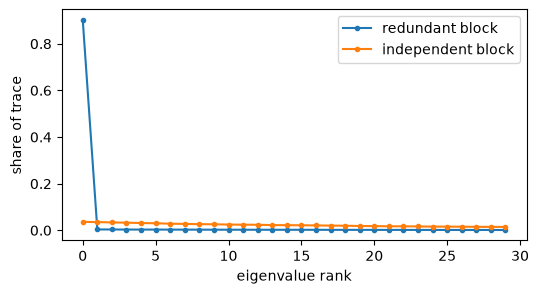

In [7]:
n = 100
latent = rng.normal(size=(n, 1))
blocks_demo = {"redundant block": latent + 0.3 * rng.normal(size=(n, 100)),
               "independent block": rng.normal(size=(n, 100))}
fig, ax = plt.subplots(figsize=(6, 3))
for name, block in blocks_demo.items():
    eig = np.sort(np.linalg.eigvalsh(ModalityKernel().fit(block).K_train_))[::-1]
    ax.plot(eig[:30] / eig.sum(), marker="o", ms=3, label=name)
    print(f"{name:18s}: top direction holds {eig[0] / eig.sum():.0%} of the kernel's total similarity")
ax.set_xlabel("eigenvalue rank")
ax.set_ylabel("share of trace")
ax.legend()
plt.show()

## Demo 4: MKL chooses β and C jointly by inner cross-validation
The heat maps show the mean inner-CV AUC of every $(\beta_s, C)$ pair, with the selected pair outlined.
- **Left:** only the structural block carries signal, so high AUC appears at large $\beta_s$.
- **Right:** only the functional block carries signal, so high AUC appears at small $\beta_s$.

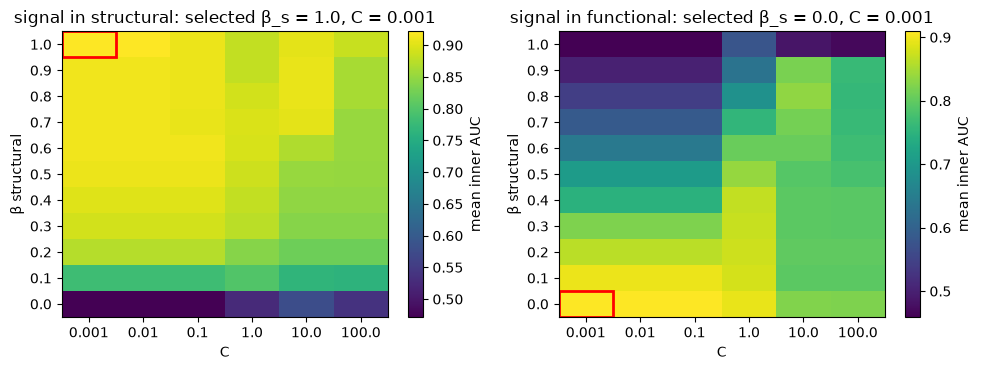

In [8]:
from sklearn.model_selection import StratifiedKFold


def simple_splits(y, k=5):
    return list(StratifiedKFold(k, shuffle=True, random_state=0).split(np.zeros(len(y)), y))


fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for ax, signal in zip(axes, ["structural", "functional"]):
    X, y, blocks = make_synthetic(n=80, signal=signal, effect=1.0, seed=1)
    mkl = KernelSVM("mkl", blocks, ["structural", "functional"], weighting="grid",
                    beta_grid=np.round(np.linspace(0, 1, 11), 1), C_grid=[0.001, 0.01, 0.1, 1, 10, 100])
    mkl.fit(X, y, simple_splits(y))
    grid = mkl.inner_results_.pivot(index="beta", columns="C", values="mean_inner_auc")
    image = ax.imshow(grid.to_numpy(), aspect="auto", origin="lower", cmap="viridis")
    ax.set_xticks(range(grid.shape[1]), grid.columns)
    ax.set_yticks(range(grid.shape[0]), grid.index)
    ax.set_xlabel("C")
    ax.set_ylabel("β structural")
    row, col = list(grid.index).index(mkl.config_["beta"]), list(grid.columns).index(mkl.config_["C"])
    ax.add_patch(plt.Rectangle((col - 0.5, row - 0.5), 1, 1, fill=False, ec="red", lw=2))
    ax.set_title(f"signal in {signal}: selected β_s = {mkl.config_['beta']}, C = {mkl.config_['C']}")
    fig.colorbar(image, ax=ax, label="mean inner AUC")
plt.tight_layout()
plt.show()

## Demo 5: MKL nests the simpler models
- With $\beta_s = 1$ fixed, MKL reproduces the structural model *exactly*.
- With $\beta_s = 0.5$, it reproduces equal-weight fusion.

This is why MKL can never be forced to be worse *by design* than these models on the training data. It can still do worse on test data, because choosing β has a cost in variance.

In [9]:
X, y, blocks = make_synthetic(n=60, signal="both")
train, test = np.arange(45), np.arange(45, 60)
inner = simple_splits(y[train], 3)
pair = ["structural", "functional"]
mkl_one = KernelSVM("mkl", blocks, pair, weighting="grid", beta_grid=[1.0], C_grid=[1.0]).fit(X[train], y[train], inner)
structural = KernelSVM("structural", blocks, ["structural"], C_grid=[1.0]).fit(X[train], y[train], inner)
mkl_half = KernelSVM("mkl", blocks, pair, weighting="grid", beta_grid=[0.5], C_grid=[1.0]).fit(X[train], y[train], inner)
equal = KernelSVM("equal", blocks, pair, weights={"structural": 0.5, "functional": 0.5}, C_grid=[1.0]).fit(X[train], y[train], inner)
print("MKL(β_s = 1)   == structural model:  ", np.allclose(mkl_one.decision_function(X[test]), structural.decision_function(X[test])))
print("MKL(β_s = 0.5) == equal-weight model:", np.allclose(mkl_half.decision_function(X[test]), equal.decision_function(X[test])))

MKL(β_s = 1)   == structural model:   True
MKL(β_s = 0.5) == equal-weight model: True


## Demo 6: stacking uses only out-of-fold scores
- **The check:** the first inner fold's OOF structural scores equal the scores of a structural SVM refit *without* those participants.
- **The output:** the meta-model's coefficients say how much each modality's score contributes.

In [10]:
base = [KernelSVM("structural", blocks, ["structural"], C_grid=[0.1, 1.0]),
        KernelSVM("functional", blocks, ["functional"], C_grid=[0.1, 1.0])]
stack = Stacking("stacking", base).fit(X[train], y[train], inner)
fold_train, fold_val = inner[0]
refit = KernelSVM("structural", blocks, ["structural"]).fit_config(X[train][fold_train], y[train][fold_train], base[0].config_)
print("OOF scores come from models that never saw those participants:",
      np.allclose(stack.oof_scores_[fold_val, 0], refit.decision_function(X[train][fold_val])))
print("meta-model:", {k: round(v, 3) if isinstance(v, float) else v for k, v in stack.selection().items()})

OOF scores come from models that never saw those participants: True
meta-model: {'inner_auc': 0.988, 'threshold': -0.182, 'C_structural': 0.1, 'meta_coef_structural': 1.421, 'C_functional': 0.1, 'meta_coef_functional': 1.974}


## Demo 7: recovering feature weights from the kernel model
**The check:** the primal weights reproduce the decision function exactly.

**What to look for:** in this synthetic data only the first 3 structural and first 5 functional features carry signal, and they get the largest weights.

primal weights reproduce the decision function: True


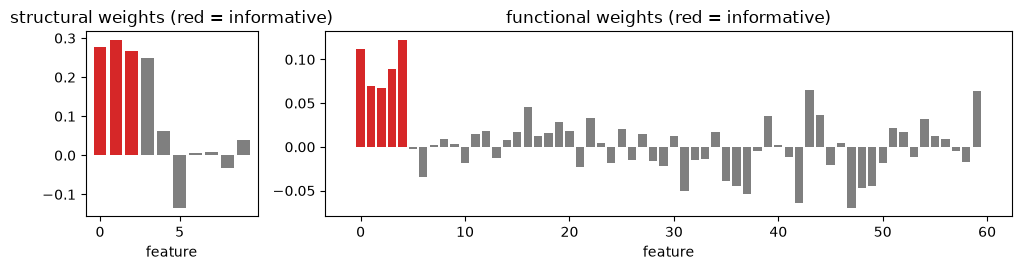

In [11]:
model = KernelSVM("equal", blocks, pair, C_grid=[1.0]).fit(X[train], y[train], inner)
w = model.primal_weights()
Z = {m: model.kernels_[m].transform_features(X[test][:, blocks[m]]) for m in pair}
reconstructed = sum(Z[m] @ w[m] for m in pair) + model.svm_.intercept_[0]
print("primal weights reproduce the decision function:", np.allclose(reconstructed, model.decision_function(X[test])))

fig, axes = plt.subplots(1, 2, figsize=(10, 2.8), gridspec_kw={"width_ratios": [1, 4]})
for ax, m, informative in [(axes[0], "structural", 3), (axes[1], "functional", 5)]:
    colors = ["tab:red" if i < informative else "tab:gray" for i in range(len(w[m]))]
    ax.bar(range(len(w[m])), w[m], color=colors)
    ax.set_title(f"{m} weights (red = informative)")
    ax.set_xlabel("feature")
plt.tight_layout()
plt.show()

## Demo 8: kernel-alignment weights (sensitivity MKL estimator)
Alignment gives more weight to the kernel whose similarities better match the labels. It does this without fitting any SVM.

In [12]:
for signal in ["structural", "functional"]:
    X_a, y_a, blocks_a = make_synthetic(n=80, signal=signal, effect=1.0, seed=2)
    kernels = {m: ModalityKernel().fit(X_a[:, blocks_a[m]]).K_train_ for m in pair}
    weights = alignment_weights(kernels, y_a)
    print(f"signal in {signal:10s} -> alignment weights: " + ", ".join(f"{m} {v:.2f}" for m, v in weights.items()))

signal in structural -> alignment weights: structural 0.79, functional 0.21
signal in functional -> alignment weights: structural 0.00, functional 1.00


## The models built from the locked configuration
`build_models` reads `configs/model_config.yaml` and returns fresh, unfitted models. Notebook 05 calls it once for every outer fold, so no model ever carries information from one fold into the next.

In [13]:
model_cfg = load_yaml(ROOT / "configs" / "model_config.yaml")
for model in build_models(model_cfg, blocks):
    kind = type(model).__name__
    detail = model.weighting if kind == "KernelSVM" else "meta-model on " + ", ".join(b.name for b in model.base_models)
    print(f"{model.name:24s} {kind:10s} {detail}")

structural               KernelSVM  fixed
functional               KernelSVM  fixed
early_fusion             KernelSVM  concat
equal_weight             KernelSVM  fixed
mkl                      KernelSVM  grid
stacking                 Stacking   meta-model on structural, functional
confounds_only           KernelSVM  fixed
mkl_alignment            KernelSVM  alignment
functional_residualized  KernelSVM  fixed
mkl_residualized         KernelSVM  grid
